# 📗 자연어 처리 — 임베딩 기반 문서 군집화

> 엔코아 AI캠퍼스 · 데이터 분석 & AI 머신러닝 캠프

지난 시간엔 문장을 **숫자 벡터(임베딩)** 로 바꾸고, 벡터끼리 **코사인 유사도**로 얼마나 비슷한지 쟀습니다. 이번 시간엔 그 임베딩을 **한 단계 더** 활용합니다 — 라벨(정답 카테고리) 없이도 비슷한 문서끼리 **저절로 묶는** **문서 군집화(클러스터링)** 입니다. 768차원 벡터를 사람이 볼 수 있는 **2차원으로 줄인 뒤**(UMAP), **HDBSCAN** 으로 **빽빽하게 모인 곳만 무리로** 잡고, 어디에도 안 붙는 문서는 **노이즈**로 남겨 둡니다. 여기서 익히는 임베딩→차원축소→군집 파이프라인이 **다음 시간 BERTopic** 의 엔진이 됩니다.

## ⏪ 복습 — 지난 시간: 임베딩과 코사인 유사도

지난 시간에 쌓은 것들이 이번 시간의 **재료**가 됩니다.

- **문장 → 임베딩**: `SentenceTransformer('jhgan/ko-sroberta-multitask')` 로 한 문장을 **768개의 숫자(벡터)** 로 바꿨습니다. 뜻이 비슷한 문장은 벡터도 가까이 놓입니다.
- **코사인 유사도**: 두 벡터가 **얼마나 같은 방향**을 가리키는지를 −1~1 로 잰 값. 1에 가까울수록 비슷합니다. `cosine_similarity(a, b)` 로 구했습니다.
- 이번 시간엔 **개별 유사도**를 넘어, 전체 문서를 **비슷한 것끼리 무리 짓는(군집화)** 데까지 나아갑니다.

**오늘의 목표**

- [ ] 문장을 **임베딩**으로 바꾸고 코사인 유사도로 비슷한 문서를 찾는다(복습).
- [ ] **UMAP** 으로 768차원 임베딩을 2차원으로 줄여 눈으로 확인한다.
- [ ] **HDBSCAN** 으로 라벨 없이 문서를 밀도 기반 무리로 묶는다.
- [ ] 무리 번호 **−1(노이즈)** 의 의미를 설명하고, `min_cluster_size` 가 결과를 어떻게 바꾸는지 확인한다.
- [ ] 각 무리에 **어떤 기사가 모였는지** 확인하고, **새 문서를 가장 비슷한 무리에 배정**한다.
- [ ] 임베딩→UMAP→군집 **전체 파이프라인**을 하나의 흐름으로 실행한다.

아래 두 셀을 먼저 실행해 라이브러리와 한국어 임베딩 모델을 준비하세요. (모델을 처음 부를 때 내려받느라 조금 걸릴 수 있어요.)

In [ ]:
# [제공 코드] 이 단원에 필요한 라이브러리와 한국어 토크나이저를 준비합니다.
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from bertopic import BERTopic
from kiwipiepy import Kiwi

sns.set_theme(style='whitegrid')
import platform

# 한글 폰트 — 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(−) 부호 깨짐 방지


c:\Users\Playdata\Desktop\enkoa-practice-data-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [제공 코드] 지난 단원에서 배운 한국어 임베딩 모델을 불러옵니다(문장→768차원 벡터).
emb_model = SentenceTransformer('jhgan/ko-sroberta-multitask')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5991.91it/s]


## 데이터 살펴보기 — 뉴스 헤드라인 1800건

이번 시간엔 **뉴스 헤드라인** 데이터를 씁니다. 네 개 분야(**스포츠·경제·IT과학·세계**)에서 각각 450건씩, 모두 1800건입니다. 각 기사가 어느 분야인지(`category`) 라벨이 붙어 있지만, **군집화는 이 라벨을 보지 않고** 문서만으로 무리를 짓습니다. 라벨은 나중에 "어느 무리에 어떤 분야가 모였나"를 **확인**할 때만 씁니다.

새 데이터를 만나면 분석 전에 **생김새부터** 봅니다 — 앞부분(`head`)·구조와 결측(`info`)·분포(`value_counts`).

In [3]:
news = pd.read_csv('data/news_4cat.csv')

print('뉴스 크기:', news.shape)
print('\n[앞부분] head()')
display(news.head())
print('\n[구조와 결측] info()')
news.info()
print('\n[분야(category) 분포]')
display(news['category'].value_counts().to_frame('건수'))

뉴스 크기: (1800, 2)

[앞부분] head()


,category,title
0,IT과학,3D 프린터로 쥐 인공난소 제작…생식기능 회복 확인
1,경제,LS네트웍스 윤선노 대표이사 사임
2,IT과학,분자탄생과정 원자움직임 1천조분의 1초단위로 실시간 관찰했다
3,세계,中안방보험 기업사냥 주춤해질 듯…매일 사들일 순 없어
4,세계,탈레반 트럼프의 협상사망 선언에도 대화문 열려 있다



[구조와 결측] info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  1800 non-null   object
 1   title     1800 non-null   object
dtypes: object(2)
memory usage: 28.3+ KB

[분야(category) 분포]


,건수
category,
IT과학,450
경제,450
세계,450
스포츠,450


---
# 1. 임베딩으로 문서를 벡터로 (복습)

## 왜 필요할까요?
컴퓨터는 글자를 직접 이해하지 못합니다. 그래서 문장을 **숫자 벡터**로 바꿔야 비교·묶기·계산이 가능합니다. 지난 시간에 배운 **임베딩 모델**이 바로 그 변환기입니다 — 뜻이 비슷한 문장은 **가까운 벡터**로 만들어 줍니다.

### 문법
- **`emb_model.encode(문장리스트)`** → `(문장 수, 768)` 모양의 벡터 배열. 문장 하나당 768개 숫자.
- **`cosine_similarity(A, B)`** → A 의 각 행과 B 의 각 행 사이 코사인 유사도 행렬(−1~1).

> 임베딩 **생성**은 시간이 걸리므로, 뉴스 1800건은 **미리 계산해 파일로 저장**해 뒀습니다(`news_embeddings.npy`). 원리는 작은 문장 몇 개로 직접 확인하고, 전체는 파일에서 불러옵니다.

In [4]:
# 작은 문장 5개로 임베딩의 원리를 직접 확인 — encode 는 (문장 수, 768) 배열을 준다
sample = [
    '손흥민이 후반 결승골을 터뜨렸다',       # 스포츠
    '국가대표 축구팀이 원정에서 승리했다',    # 스포츠
    '코스피 지수가 외국인 매수에 상승 마감했다',  # 경제
    '원달러 환율이 급등하며 원화가 약세다',   # 경제
    '새 인공지능 반도체가 공개됐다',          # IT과학
]
sample_vecs = emb_model.encode(sample)
print('임베딩 배열 모양:', sample_vecs.shape, '  (문장 5개 × 768차원)')

# 문장끼리 코사인 유사도 — 같은 분야 문장이 더 비슷하게 나온다
sim_matrix = cosine_similarity(sample_vecs, sample_vecs)
print('\n[문장 사이 코사인 유사도]')
display(pd.DataFrame(sim_matrix.round(2), index=range(len(sample)), columns=range(len(sample))))
print('0↔1(축구 두 문장), 2↔3(경제 두 문장)의 유사도가 서로 다른 분야보다 높다')

임베딩 배열 모양: (5, 768)   (문장 5개 × 768차원)

[문장 사이 코사인 유사도]


,0,1,2,3,4
0,1.00,0.31,0.23,0.01,0.09
1,0.31,1.00,0.20,0.03,0.04
2,0.23,0.20,1.00,0.22,-0.02
3,0.01,0.03,0.22,1.00,-0.05
4,0.09,0.04,-0.02,-0.05,1.00


0↔1(축구 두 문장), 2↔3(경제 두 문장)의 유사도가 서로 다른 분야보다 높다


In [5]:
# 전체 1800건 임베딩 — 저장된 파일이 있으면 불러오고, 없으면 지금 만들어 저장한다
emb_path = 'data/news_embeddings.npy'
if os.path.exists(emb_path):
    embeddings = np.load(emb_path)                       # 저장돼 있으면 바로 불러온다(빠름)
    print('저장된 임베딩을 불러왔습니다:', embeddings.shape)
else:
    print('저장된 임베딩이 없어 지금 만듭니다 — 1800건이라 수 분 걸릴 수 있어요')
    embeddings = emb_model.encode(news['title'].tolist(), show_progress_bar=False)
    np.save(emb_path, embeddings)                        # 다음부터는 위 if 로 빠지도록 저장
    print('만들어 저장했습니다:', embeddings.shape, '->', emb_path)

# 0번 기사와 가장 비슷한 기사 top3 찾기 (자기 자신 제외)
sims = cosine_similarity(embeddings[0:1], embeddings)[0]
top3 = np.argsort(-sims)[1:4]        # 내림차순 1~3위 (0위는 자기 자신)
print('\n기준 기사[0]:', news.iloc[0]['title'], '(', news.iloc[0]['category'], ')')
print('\n가장 비슷한 기사 top3:')
for i in top3:
    print(f"  유사도 {sims[i]:.2f}  [{news.iloc[i]['category']}] {news.iloc[i]['title']}")
print('\n→ IT과학 기사의 이웃이 모두 IT과학 — 임베딩이 뜻을 잘 담고 있다')

저장된 임베딩을 불러왔습니다: (1800, 768)

기준 기사[0]: 3D 프린터로 쥐 인공난소 제작…생식기능 회복 확인 ( IT과학 )

가장 비슷한 기사 top3:
  유사도 0.52  [IT과학] 혈액 만드는 조혈줄기세포 제작법 개발
  유사도 0.49  [IT과학] 항생제 네오마이신 바이러스 예방 효과…쥐 실험서 확인
  유사도 0.48  [IT과학] 레고 조립하듯 염색체 제작…2년 내에 100% 인공효모 나온다

→ IT과학 기사의 이웃이 모두 IT과학 — 임베딩이 뜻을 잘 담고 있다


### 🖐️ 함께 따라하기 — 두 문장의 유사도 직접 재보기

짧은 문장 두 개를 임베딩해 코사인 유사도를 직접 구해 봅니다.

In [6]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) two = ['프로야구 개막전이 열렸다', '야구 경기가 시작됐다'] 를 만든다
# 2) emb_model.encode(two) 로 벡터를 만들어 vecs 에 담는다
# 3) cosine_similarity(vecs[0:1], vecs[1:2])[0][0] 로 두 문장 유사도를 소수 셋째 자리로 출력한다

### ✅ 바로 확인 퀴즈

**1.** `emb_model.encode(['문장 A', '문장 B', '문장 C'])` 의 결과 모양(shape)은 무엇인가요?

<details><summary>정답 보기</summary>

`(3, 768)` 입니다. 문장 3개가 각각 768차원 벡터로 바뀌므로 **행 3개 · 열 768개** 배열이 됩니다.

</details>

**2.** "배송이 정말 빨라요" 와 "배송이 정말 느려요" 는 **뜻이 정반대**입니다. 이 둘의 코사인 유사도가 낮을까요?

<details><summary>정답 보기</summary>

아니요, **0.55 로 꽤 높습니다**(전혀 다른 주제인 "코스피 지수가 상승 마감했다" 와는 0.02). 임베딩은 "무엇에 대한 말인가"(주제·어휘·문장 구조)를 주로 담고 **좋다/나쁘다 같은 방향은 약하게** 담기 때문입니다. 그래서 유사도가 높다고 **같은 뜻**이라 단정하면 안 되고 "비슷한 화제" 정도로 읽어야 합니다.

</details>

---
# 2. UMAP — 768차원을 2차원으로 줄이기

## 왜 필요할까요?
임베딩은 768차원입니다. 사람은 2~3차원까지만 눈으로 볼 수 있으니, **비슷한 것은 가깝게, 다른 것은 멀게** 유지하면서 차원을 **확 줄여** 그림으로 봐야 합니다. 이 일을 하는 대표 도구가 **UMAP** 입니다.

### 비유
지구본(3차원)을 세계지도(2차원)로 펼치는 것과 같습니다. 완벽하진 않지만 **가까운 나라끼리는 지도에서도 가깝게** 놓이도록 펼칩니다. UMAP 은 임베딩 공간에서 **이웃 관계를 최대한 보존**하며 평면에 펼칩니다.

### 문법 — 주요 파라미터
| 파라미터 | 뜻 | 이번 설정 |
|---|---|---|
| `n_components` | 줄일 목표 차원 수 | `2` (그림용) |
| `n_neighbors` | 이웃을 몇 개까지 볼지(작으면 국소, 크면 전역) | `15` |
| `min_dist` | 점들을 얼마나 촘촘히 모을지(작을수록 빽빽) | `0.1` |
| `metric` | 거리 척도 | `'cosine'` (임베딩엔 코사인) |
| `random_state` | 난수 고정(재현성) | `42` |

> 전체 1800건의 2차원 좌표도 **미리 계산해 저장**해 뒀습니다(`news_umap2d.npy`) — 누구 컴퓨터에서든 **같은 그림**이 나오도록. UMAP 을 만드는 방법은 아래에서 보이되, 좌표는 파일에서 불러옵니다.

In [7]:
# UMAP 을 만드는 방법 (설명용) — 실제 좌표는 미리 계산해 저장한 파일을 쓴다
umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                  metric='cosine', random_state=42)
print('UMAP 설정 완료:', umap_model)

# 2차원 좌표 — 임베딩과 똑같이, 저장돼 있으면 불러오고 없으면 위 umap_model 로 만들어 저장한다
umap_path = 'data/news_umap2d.npy'
if os.path.exists(umap_path):
    umap2d = np.load(umap_path)                          # 모든 머신에서 동일한 재현 좌표
    print('저장된 2차원 좌표를 불러왔습니다:', umap2d.shape)
else:
    print('저장된 좌표가 없어 지금 만듭니다 — UMAP 학습에 시간이 걸립니다')
    umap2d = umap_model.fit_transform(embeddings)        # 위에서 만든 설정을 그대로 사용
    np.save(umap_path, umap2d)
    print('만들어 저장했습니다:', umap2d.shape, '->', umap_path)

UMAP 설정 완료: UMAP(metric='cosine', random_state=42)
저장된 2차원 좌표를 불러왔습니다: (1800, 2)


이제 2차원 좌표를 **실제 분야(category)별 색**으로 흩뿌려 봅니다. 라벨이 비슷한 기사끼리 **저절로 뭉쳐** 있으면, 임베딩이 분야 차이를 잘 담았다는 뜻입니다.

<img src="images/교안/umap_category.png" width="620">

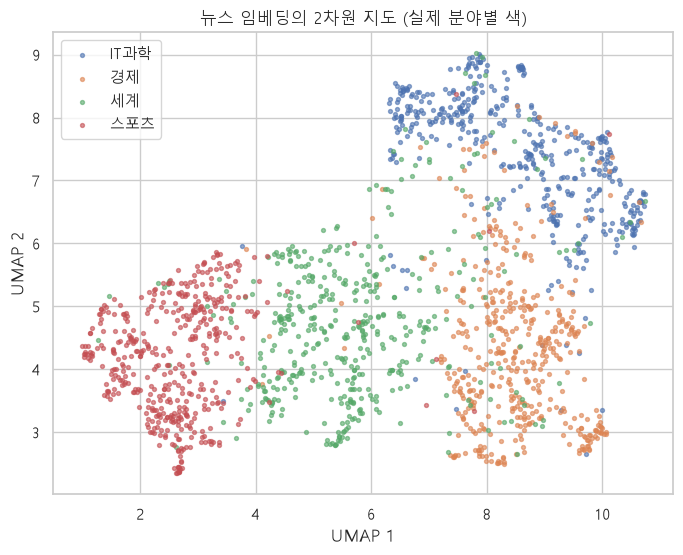

같은 분야 기사들이 덩어리로 모여 있다 — 임베딩이 분야 차이를 잘 담았다는 신호


In [8]:
# 분야별 색으로 2차원 산점도 — 비슷한 기사끼리 뭉쳐 있는지 눈으로 확인
plt.figure(figsize=(8, 6))
for cat in news['category'].unique():
    mask = news['category'].values == cat
    plt.scatter(umap2d[mask, 0], umap2d[mask, 1], s=8, alpha=0.6, label=cat)
plt.title('뉴스 임베딩의 2차원 지도 (실제 분야별 색)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.show()
print('같은 분야 기사들이 덩어리로 모여 있다 — 임베딩이 분야 차이를 잘 담았다는 신호')

### ✅ 바로 확인 퀴즈

**1.** 산점도에서 두 점이 **아주 가까이** 붙어 있습니다. 이 두 기사에 대해 무엇을 말할 수 있고, 무엇은 말할 수 없나요?

<details><summary>정답 보기</summary>

**말할 수 있는 것**: 768차원 공간에서도 이웃일 가능성이 높다 — UMAP 이 가까운 것을 가깝게 유지하니까요. **말할 수 없는 것**: "거리가 2배면 2배 다르다" 같은 **거리의 크기**와 축의 의미입니다. UMAP 의 x·y 축은 아무 뜻이 없고 눈금 간격도 해석 대상이 아닙니다 — **가까움(이웃 관계)만** 읽으세요.

</details>

**2.** 같은 코드로 산점도를 그렸는데 네 분야가 서로 **뒤죽박죽 섞여** 나왔다고 합시다. 무엇을 의심해야 할까요? (두 가지)

<details><summary>정답 보기</summary>

① **임베딩이 그 차이를 못 담았다** — 한국어에 약한 모델을 썼거나, 문장이 너무 짧아 단서가 부족한 경우입니다. ② **분야 차이가 애초에 본문에 안 드러난다** — 라벨은 다르지만 실제 문장이 비슷하면 임베딩도 비슷할 수밖에 없습니다. (UMAP 을 의심하는 것은 마지막입니다 — 차원 축소는 **없는 차이를 만들어 내지 못합니다.**)

</details>

---
# 3. HDBSCAN — 밀도로 묶고, 애매한 건 노이즈로

## 왜 필요할까요?
지도를 눈으로 보면 덩어리가 보이지만, 컴퓨터가 "이 기사는 몇 번 군집"이라고 **자동으로 나눠** 줘야 활용할 수 있습니다. 그런데 실제 문서는 **크기가 고른 덩어리로 딱 떨어지지 않습니다** — 큰 덩어리도 있고 작은 덩어리도 있고, "어디에도 안 어울리는" 기사도 섞여 있습니다.

**HDBSCAN** 은 점들이 **빽빽하게 모인 곳만** 군집(cluster, 덩어리)으로 잡습니다. 그래서 군집을 몇 개 만들지 사람이 정해 줄 필요가 없고(데이터의 밀도가 정합니다), 어디에도 확실히 붙지 못한 점은 억지로 끼워 넣지 않고 **노이즈(−1)** 로 남겨 둡니다.

### 비유
밤에 찍은 도시 항공사진에서 **불빛이 몰린 곳을 동네로** 표시한다고 생각해 보세요. 동네를 몇 개 그릴지 미리 정하지 않아도, 불빛이 촘촘한 곳이 저절로 동네가 됩니다. 들판에 하나씩 떨어져 있는 불빛은 어느 동네에도 넣지 않고 그냥 **홀로 남겨** 둡니다 — 그게 노이즈입니다.

<img src="images/교안/HDBSCAN_밀도군집.png" width="900">

### 문법
- **`HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom')`** — 군집으로 인정할 최소 크기 15, 유클리드 거리, 군집 선택 방식 'eom'.
- **`.fit_predict(좌표)`** → 군집 번호 배열. **−1 은 노이즈**(어느 군집에도 안 든 점).

| 파라미터 | 뜻 | 크게 하면 |
|---|---|---|
| `min_cluster_size` | 군집으로 인정할 최소 문서 수 | 작은 군집이 사라져 **군집 개수가 줄어듦** |
| `metric` | 거리 척도 | 2차원 좌표에는 보통 `'euclidean'` |

> **이 임베딩→UMAP→HDBSCAN 파이프라인이 바로 다음 시간에 배울 BERTopic 의 내부 엔진**입니다. BERTopic 은 여기에 "각 군집의 대표 키워드 뽑기"를 더한 것이고, 여기서 본 노이즈(−1)가 BERTopic 에서는 **토픽 −1** 이라는 이름으로 그대로 나타납니다.

In [21]:
# HDBSCAN: 무리 개수를 정해 주지 않고 밀도로 묶는다. -1 은 노이즈
hdb = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom')
hdb_labels = hdb.fit_predict(umap2d)

n_groups = len(set(hdb_labels) - {-1})
n_noise = int((hdb_labels == -1).sum())
print('찾은 군집 수:', n_groups)
print('노이즈(-1)로 남은 기사:', n_noise, '건 / 전체', len(hdb_labels), '건')
print('\n[군집별 크기]')
display(pd.Series(hdb_labels).value_counts().sort_index().to_frame('건수').rename_axis('군집 번호'))

찾은 군집 수: 16
노이즈(-1)로 남은 기사: 596 건 / 전체 1800 건

[군집별 크기]


,건수
군집 번호,
-1,596
0,47
1,21
2,307
3,182
4,49
5,51
6,49
7,22


묶은 결과(군집 번호)와 **실제 분야**를 나란히 그려 봅니다. 왼쪽에서 **회색**은 노이즈(−1)입니다.

두 그림을 견주면 두 가지가 보입니다. ① 군집 하나하나가 **한 분야 안에 들어앉아** 있습니다 — 라벨을 전혀 보지 않았는데 분야의 경계를 알아본 것입니다. ② 그런데 군집 개수는 분야 4개보다 **훨씬 많습니다**. HDBSCAN 은 "경제" 같은 큰 분야를 통째로 잡는 게 아니라 그 안의 **더 좁은 주제 덩어리**(증시·부동산 …)를 잡기 때문입니다. 덩어리 사이 **경계에 걸친 기사**들은 회색, 즉 노이즈로 남습니다.

> 노이즈가 전체의 3분의 1쯤 됩니다. 헤드라인은 문장이 짧아 주제 경계가 흐릿하기 때문이며, **정상적인 결과**입니다. 다음 시간 BERTopic 에서도 **토픽 −1** 이 이만큼 크게 나옵니다.

<img src="images/교안/hdbscan_vs_category.png" width="820">

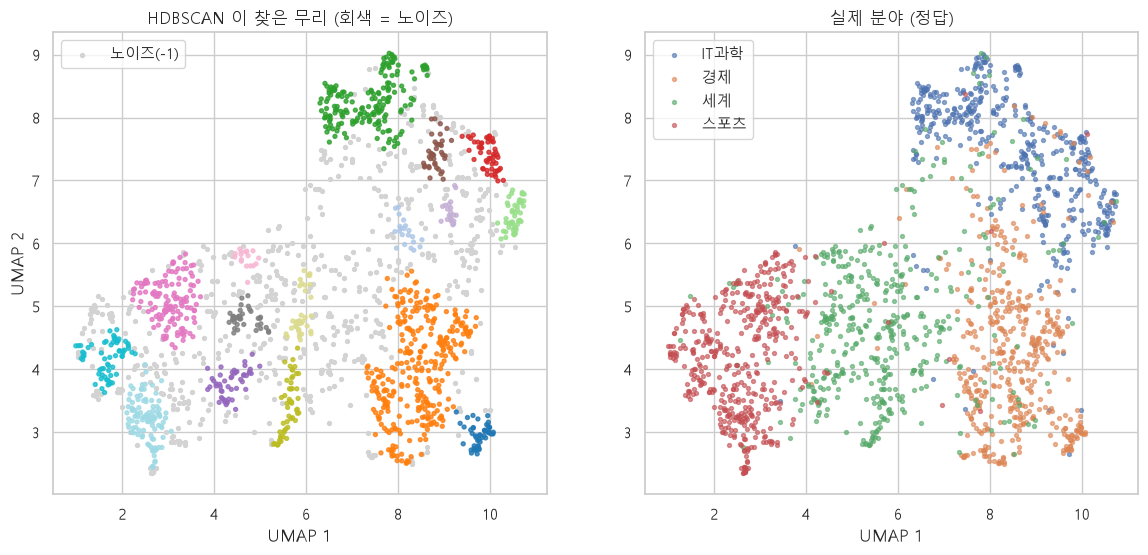

무리가 분야보다 잘게 쪼개져 있다 — 각 무리는 한 분야 안의 더 좁은 주제 덩어리다


In [12]:
# 왼쪽: HDBSCAN 무리(회색=노이즈) / 오른쪽: 실제 분야 — 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

is_noise = hdb_labels == -1
axes[0].scatter(umap2d[is_noise, 0], umap2d[is_noise, 1], s=8, color='lightgray', label='노이즈(-1)')
axes[0].scatter(umap2d[~is_noise, 0], umap2d[~is_noise, 1],
                c=hdb_labels[~is_noise], cmap='tab20', s=8, alpha=0.8)
axes[0].set_title('HDBSCAN 이 찾은 무리 (회색 = 노이즈)')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2'); axes[0].legend()

for cat in news['category'].unique():
    mask = news['category'].values == cat
    axes[1].scatter(umap2d[mask, 0], umap2d[mask, 1], s=8, alpha=0.6, label=cat)
axes[1].set_title('실제 분야 (정답)')
axes[1].set_xlabel('UMAP 1'); axes[1].legend()
plt.show()
print('무리가 분야보다 잘게 쪼개져 있다 — 각 무리는 한 분야 안의 더 좁은 주제 덩어리다')

군집 번호만으로는 **그 군집이 무엇에 대한 것인지** 알 수 없습니다. 각 군집에 실제로 어떤 분야의 기사가 모였는지, 그리고 제목이 어떤 것들인지 직접 들여다봅니다.

In [20]:
# 무리마다 어떤 분야의 기사가 모였나 — 교차표로 한눈에
tab = pd.crosstab(pd.Series(hdb_labels, name='군집 번호'), news['category'])
print('[무리 × 실제 분야] (앞부분)')
display(tab.head(8))

# 가장 큰 무리 하나를 골라 제목을 직접 확인
big = tab.drop(index=-1).sum(axis=1).idxmax() #-1 군집 제외 하고 행방향 합 최댓값 인덱스 얻기
print(f'\n가장 큰 무리 {big} 번의 기사 제목 5개:')
for t in news.loc[hdb_labels == big, 'title'].head(5):
    print(' -', t)
print('\n한 군집에 같은 분야 기사가 몰려 있다 — 군집이 곧 주제 덩어리다')

[무리 × 실제 분야] (앞부분)


category,IT과학,경제,세계,스포츠
군집 번호,,,,
-1,127,95,218,156
0,1,46,0,0
1,1,17,2,1
2,5,278,23,1
3,171,3,7,1
4,44,2,3,0
5,45,5,1,0
6,0,1,41,7



가장 큰 무리 2 번의 기사 제목 5개:
 - 中안방보험 기업사냥 주춤해질 듯…매일 사들일 순 없어
 - 신풍제약 자사주 2천억원어치 매각…장중 주가 24% 급락
 - 전국민 고용보험 소득 따라 보험료 부과…사용자는 이윤 기준
 - 특징주 공인인증서 폐지 가능성에 관련 수혜주 급등
 - 그래픽 가계·개인사업자 빛 2천 조 돌파

한 군집에 같은 분야 기사가 몰려 있다 — 군집이 곧 주제 덩어리다


### 🖐️ 함께 따라하기 — 최소 무리 크기를 키워 보기

`min_cluster_size` 를 **30** 으로 키우면 무리 수와 노이즈가 어떻게 달라지는지 확인해 봅니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) HDBSCAN(min_cluster_size=30, metric='euclidean', cluster_selection_method='eom') 을 만든다
# 2) fit_predict(umap2d) 로 labels 를 만든다
# 3) 무리 수(-1 제외)와 노이즈 개수를 출력한다

### ✅ 바로 확인 퀴즈

**1.** HDBSCAN 결과에서 무리 번호가 **−1** 인 점은 무엇을 뜻하나요?

<details><summary>정답 보기</summary>

**노이즈** — 주변이 충분히 빽빽하지 않아 어느 무리에도 확실히 들지 못한 점입니다. HDBSCAN 은 이런 점을 억지로 어딘가에 넣지 않고 −1 로 남겨 둡니다.

</details>

**2.** 노이즈가 전체의 3분의 1이나 나왔습니다. 이걸 **줄이고 싶다면** `min_cluster_size` 를 어느 쪽으로 움직여야 하고, 그 대가로 무엇을 잃나요?

<details><summary>정답 보기</summary>

**낮춥니다.** 작은 덩어리도 무리로 인정되니 더 많은 점이 어딘가에 소속됩니다. 대가는 **무리가 잘게 쪼개져 수가 늘고, 우연히 뭉친 잡무리까지 무리로 잡힌다**는 것입니다. 즉 "모두를 어딘가에 넣기"와 "무리마다 뚜렷한 주제를 갖기"는 서로 맞바꾸는 관계라, 정답 값은 없고 **목적에 따라** 고릅니다.

</details>

**3.** HDBSCAN 은 학습할 때 실제 분야(정답 라벨)를 사용하나요?

<details><summary>정답 보기</summary>

아니요. **좌표만** 보고 빽빽한 곳을 찾는 **비지도 학습**입니다. 라벨은 나중에 "어떤 분야가 모였나"를 사람이 확인할 때만 씁니다.

</details>

### 새 문서는 어느 군집에 속할까? — 군집 대표 벡터 + 코사인 유사도

군집을 찾아 두면, 각 군집에 속한 문서들의 **임베딩 평균**을 그 군집의 **대표 벡터**로 삼을 수 있습니다(노이즈 −1 은 대표를 만들지 않습니다 — 하나의 주제가 아니니까요). 새로 들어온 문서를 임베딩해 **어느 대표 벡터와 가장 비슷한지** 코사인 유사도로 재면, 군집화를 다시 돌리지 않고도 그 문서를 **가장 가까운 군집에 배정**할 수 있습니다.

> 지금은 이 배정을 **손으로** 합니다(대표 벡터 만들기 → 유사도 재기 → 최댓값 고르기). 다음 시간 BERTopic 에서는 같은 일을 **`transform` 한 줄**로 하게 됩니다 — 오늘 손으로 해 봐야 그 한 줄이 안에서 무엇을 하는지 알 수 있습니다.

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

result = np.vstack([a, b]) #여러 배열을 세로(행 방향)로 쌓아 하나로 합치는 함수
print(result.shape)

(2, 3)


In [25]:
# 군집마다 '대표 벡터' 만들기 — 그 군집 문서들의 임베딩 평균 (노이즈 -1 은 제외)
group_ids = sorted(set(hdb_labels) - {-1})
centers = np.vstack([embeddings[hdb_labels == g].mean(axis=0) for g in group_ids])
print('대표 벡터 모양:', centers.shape, '  (무리 수 × 768차원)')

new_titles = ['프로야구 개막전 매진 행렬', '새 스마트폰 카메라 성능 공개']
new_vec = emb_model.encode(new_titles)
sims = cosine_similarity(new_vec, centers)      # (새 문서 2개, 무리 수) 유사도
nearest = [group_ids[i] for i in sims.argmax(axis=1)]

display(pd.DataFrame({'새 문서': new_titles, '배정된 군집': nearest,
                      '최대 유사도': sims.max(axis=1).round(3)}))

# 배정이 맞는지는 '그 군집에 원래 어떤 기사가 있었나'를 보면 안다
for t, g in zip(new_titles, nearest):
    print(f'\n[{t}] -> 군집 {g} 의 기존 기사:')
    for old in news.loc[hdb_labels == g, 'title'].head(3):
        print('   -', old)

대표 벡터 모양: (16, 768)   (무리 수 × 768차원)


,새 문서,배정된 군집,최대 유사도
0,프로야구 개막전 매진 행렬,15,0.460
1,새 스마트폰 카메라 성능 공개,4,0.627



[프로야구 개막전 매진 행렬] -> 군집 15 의 기존 기사:
   - 홍창화 응원단장 1천경기 한화 응원단 위한 행사
   - 특급 활약 김강민 SK 우승 DNA 올해 잘 맞물렸다
   - 힐만 감독 실책 아쉬움에 펑고 삼매경…기초에 집중

[새 스마트폰 카메라 성능 공개] -> 군집 4 의 기존 기사:
   - 삼성전자 갤럭시A70 공개…6.7인치 화면에 고용량 배터리
   - 워즈니악 아이폰 X 출시 첫날 사지 않은 첫 아이폰 될 것
   - 가전의 심장 모터·컴프레서…LG 가혹한 품질실험


### 🖐️ 함께 따라하기 — 어느 무리에도 안 어울리는 문서

위 두 문장은 뉴스 네 분야에 잘 맞는 문장이었습니다. 이번엔 **이 코퍼스에 없는 주제**의 문장을 넣어, 배정된 무리와의 **최대 유사도가 얼마나 낮은지** 확인해 봅니다. (대표 벡터 방식은 −1 을 돌려주지 않고 **무조건 가장 가까운 무리**를 고르기 때문에, "얼마나 가까운가"를 사람이 직접 봐야 합니다.)

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) odd = ['오늘 저녁 된장찌개 끓이는 법'] 을 만들어 emb_model.encode 로 벡터화한다
# 2) 위에서 만든 centers 와 cosine_similarity 를 구한다
# 3) 배정된 무리 번호와 그때의 최대 유사도를 출력해, 앞 두 문장의 유사도와 견줘 본다

### ✅ 바로 확인 퀴즈

**1.** 대표 벡터 방식은 어떤 문서를 넣어도 **반드시 어떤 무리 하나**를 돌려줍니다. 그런데 HDBSCAN 은 애매한 문서를 −1 로 남기죠. 이 차이 때문에 무엇을 조심해야 하나요?

<details><summary>정답 보기</summary>

**"배정됐다"가 "어울린다"를 뜻하지 않는다**는 점입니다. `argmax` 는 가장 가까운 것을 고를 뿐이라, 전혀 다른 주제의 문서도 어딘가에는 배정됩니다. 그래서 **최대 유사도 값**을 함께 보고, 너무 낮으면 "어느 무리에도 안 어울림"으로 직접 처리해야 합니다.

</details>

---
## 🚀 응용 클론코딩 — 임베딩 군집화 파이프라인 한 흐름

§3 에서 무리를 **찾는** 것까지 했습니다. 이번엔 한 걸음 더 나아가, 찾은 무리마다 **이름을 붙여** 봅니다 — 각 무리에서 기사 제목 2개를 뽑아 읽고 "이 무리는 무엇에 대한 무리인가"를 사람이 판단하는 것입니다. 큰 무리 5개만 다뤄 봅시다.

> 다 하고 나면 이런 생각이 들 겁니다 — **"무리가 20개면 이걸 20번 해야 하나?"** 바로 그 수작업을 자동으로 해 주는 것이 다음 시간의 **c-TF-IDF** 입니다.

In [ ]:
# 🚀 응용 (아래 순서대로 직접 작성해 보세요)
# 1) 앞에서 만든 hdb_labels 로 무리별 크기를 세고, 노이즈(-1)를 뺀 뒤 큰 순서로 5개를 고른다
#    (힌트: pd.Series(hdb_labels).value_counts() 는 이미 큰 순서다)
# 2) 그 5개 무리 각각에 대해 반복하며:
#    2-1) 무리 번호와 크기를 출력한다
#    2-2) news 에서 그 무리에 속한 기사 제목 2개를 출력한다
#    2-3) 그 무리에 실제로 어떤 분야가 가장 많은지도 함께 출력한다
#         (news.loc[hdb_labels == g, 'category'].mode()[0])
# 3) 출력을 읽고, 무리마다 어울리는 이름을 머릿속으로 붙여 본다

---
## 이번 강의 정리

| 단계 | 도구 | 함수 |
|---|---|---|
| 문서 → 벡터 | 임베딩 모델 | `emb_model.encode` |
| 벡터 유사도 | 코사인 유사도 | `cosine_similarity` |
| 768차원 → 2차원 | UMAP | `UMAP(n_components=2, ...)` |
| 밀도로 묶기(+노이즈) | HDBSCAN | `HDBSCAN(min_cluster_size=..).fit_predict` |
| 무리 안 들여다보기 | 교차표·제목 확인 | `pd.crosstab` |
| 새 문서 배정 | 무리 대표 벡터 + 코사인 유사도 | `cosine_similarity` |

- **군집화는 라벨 없이** 비슷한 문서를 묶습니다. 라벨은 나중에 "어떤 분야가 모였나"를 **확인**할 때만 씁니다.
- **HDBSCAN 은 무리 개수를 스스로** 정합니다 — 빽빽하게 모인 곳만 무리로 잡기 때문입니다.
- 어디에도 확실히 붙지 못한 문서는 **노이즈(−1)** 로 남습니다. 억지로 끼워 넣지 않는 것이 장점입니다.
- `min_cluster_size` 가 결과를 크게 바꿉니다 — **키우면 무리가 굵고 적게, 줄이면 잘게** 쪼개집니다.

## ⏭️ 예고 — 다음 시간: BERTopic 토픽 모델링

이번 시간엔 문서를 **무리로 묶기**까지 했습니다. 그런데 "이 무리는 **무슨 주제**인가?"는 결국 기사 제목을 하나씩 열어 사람이 읽어야 알 수 있었죠. 다음 시간엔 각 무리의 **대표 키워드를 자동으로 뽑아** 주제를 붙이는 **BERTopic** 을 배웁니다.
- 오늘의 **임베딩 → UMAP → HDBSCAN** 파이프라인이 BERTopic 의 **내부 엔진**입니다.
- 여기에 **c-TF-IDF 키워드 추출**을 더하면, 무리마다 "야구·축구", "금리·환율" 같은 **주제 키워드**가 나옵니다.

오늘 익힌 군집화가 그대로 토픽 모델링의 바탕이 됩니다. 수고하셨습니다!